# New Section

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st

In [57]:
# pricing
import numpy as np

def binomial_option_pricing(S, K, T, r, sigma, N, option_type='call', style='european'):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    discount = np.exp(-r * dt)

    # Asset Price Tree
    asset_prices = np.zeros((N + 1, N + 1))
    asset_prices[0, 0] = S
    for i in range(1, N + 1):
        asset_prices[i, 0] = asset_prices[i - 1, 0] * u
        for j in range(1, i + 1):
            asset_prices[i, j] = asset_prices[i - 1, j - 1] * d

    # Option Value Tree
    option_values = np.zeros_like(asset_prices)
    for j in range(N + 1):
        if option_type == 'call':
            option_values[N, j] = max(0, asset_prices[N, j] - K)
        else:
            option_values[N, j] = max(0, K - asset_prices[N, j])

    for i in range(N - 1, -1, -1):
        for j in range(i + 1):
            hold = discount * (p * option_values[i + 1, j] + (1 - p) * option_values[i + 1, j + 1])
            if style == 'american':
                if option_type == 'call':
                    exercise = max(0, asset_prices[i, j] - K)
                else:
                    exercise = max(0, K - asset_prices[i, j])
                option_values[i, j] = max(hold, exercise)
            else:
                option_values[i, j] = hold

    return option_values[0, 0], asset_prices,option_values


In [28]:
# # calling the model locally
# price , price_tree, option_tree= binomial_option_pricing(
#     S=140,       # Spot price
#     K=80,       # Strike price
#     T=1/9,         # Time to maturity (in years)
#     r=0.065,      # Risk-free interest rate
#     sigma=0.68,   # Volatility
#     N=6,         # Number of steps in the binomial tree
#     option_type='call',    # 'call' or 'put'
#     style='american'       # 'european' or 'american'
# )

# print("Option Price:", round(price, 1))
# print(price_tree)
# print(option_tree)

Option Price: 60.6
[[140.           0.           0.           0.           0.
    0.           0.        ]
 [153.57341123 127.62625928   0.           0.           0.
    0.           0.        ]
 [168.46280456 140.         116.34615755   0.           0.
    0.           0.        ]
 [184.7957683  153.57341123 127.62625928 106.06303478   0.
    0.           0.        ]
 [202.71226085 168.46280456 140.         116.34615755  96.68877412
    0.           0.        ]
 [222.36580998 184.7957683  153.57341123 127.62625928 106.06303478
   88.14304682   0.        ]
 [243.92482843 202.71226085 168.46280456 140.         116.34615755
   96.68877412  80.3526239 ]]
[[ 60.57569637   0.           0.           0.           0.
    0.           0.        ]
 [ 74.05344671  48.10629476   0.           0.           0.
    0.           0.        ]
 [ 88.84706393  60.38425937  36.73041692   0.           0.
    0.           0.        ]
 [105.08413621  73.86177914  47.91462719  26.35140269   0.
    0.           

In [29]:
# # temporary view of prcing in streamlit app
# %%writefile binomial_app.py
# import streamlit as st
# import numpy as np
# import pandas as pd

# st.title("📈 Binomial Option Pricing Calculator")

# # Inputs
# S = st.number_input("Spot Price (S)", value=100.0)
# K = st.number_input("Strike Price (K)", value=100.0)
# T = st.number_input("Time to Maturity (T, in years)", value=1.0)
# r = st.number_input("Risk-Free Interest Rate (r)", value=0.05, format="%.4f", step=0.0001)
# sigma = st.number_input("Volatility (σ)", value=0.2)
# N = st.slider("Number of Steps (N)", min_value=1, max_value=100, value=3)
# option_type = st.selectbox("Option Type", ("call", "put"))
# style = st.selectbox("Option Style", ("european", "american"))

# # Binomial Pricing Logic
# def binomial_option_pricing(S, K, T, r, sigma, N, option_type='call', style='european'):
#     dt = T / N
#     u = np.exp(sigma * np.sqrt(dt))
#     d = 1 / u
#     p = (np.exp(r * dt) - d) / (u - d)
#     discount = np.exp(-r * dt)

#     # Asset Price Tree
#     asset_prices = np.zeros((N + 1, N + 1))
#     asset_prices[0, 0] = S
#     for i in range(1, N + 1):
#         asset_prices[i, 0] = asset_prices[i - 1, 0] * u
#         for j in range(1, i + 1):
#             asset_prices[i, j] = asset_prices[i - 1, j - 1] * d

#     # Option Value Tree
#     option_values = np.zeros_like(asset_prices)
#     for j in range(N + 1):
#         if option_type == 'call':
#             option_values[N, j] = max(0, asset_prices[N, j] - K)
#         else:
#             option_values[N, j] = max(0, K - asset_prices[N, j])

#     for i in range(N - 1, -1, -1):
#         for j in range(i + 1):
#             hold = discount * (p * option_values[i + 1, j] + (1 - p) * option_values[i + 1, j + 1])
#             if style == 'american':
#                 if option_type == 'call':
#                     exercise = max(0, asset_prices[i, j] - K)
#                 else:
#                     exercise = max(0, K - asset_prices[i, j])
#                 option_values[i, j] = max(hold, exercise)
#             else:
#                 option_values[i, j] = hold

#     return option_values[0, 0], asset_prices, option_values

# Calculate and Display
# price, asset_tree, option_tree = binomial_option_pricing(S, K, T, r, sigma, N, option_type, style)
# st.subheader(f"📌 Option Price: `{price:.4f}`")

# # Display Trees as Tables
# asset_df = pd.DataFrame('', index=range(N+1), columns=range(N+1))
# opt_df = pd.DataFrame('', index=range(N+1), columns=range(N+1))

# for i in range(N+1):
#     for j in range(i+1):
#         asset_df.iloc[i, j] = f"{asset_tree[i, j]:.2f}"
#         opt_df.iloc[i, j] = f"{option_tree[i, j]:.2f}"

# st.write("📊 Asset Price Tree")
# st.dataframe(asset_df)

# st.write(f"📊 Option Value Tree ({style.title()} {option_type.title()})")
# st.dataframe(opt_df)


Overwriting binomial_app.py


In [ ]:
# from google.colab import files
# files.download('binomial_app.py')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
# 2. Function for heatmap visualization over spot and volatility ranges
def option_price_heatmap(K, T, r, N, option_type, style,
                         spot_min, spot_max, spot_steps,
                         vol_min, vol_max, vol_steps):
    spot_range = np.linspace(spot_min, spot_max, spot_steps)
    vol_range = np.linspace( vol_max,vol_min, vol_steps)

    heatmap_data = np.zeros((len(vol_range), len(spot_range)))

    for i, sigma in enumerate(vol_range):
        for j, S_val in enumerate(spot_range):
            price, _, _ = binomial_option_pricing(
                S=S_val, K=K, T=T, r=r, sigma=sigma,
                N=N, option_type=option_type, style=style
            )
            heatmap_data[i, j] = price

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(
        heatmap_data,
        xticklabels=np.round(spot_range, 0),
        yticklabels=np.round(vol_range, 2),
        cmap='RdYlGn',
        annot=True,                  # <--- annotate each cell
        fmt=".1f",
        annot_kws={"size": 7},
        cbar=True,
        linewidths=0.5,
        ax=ax
    )
    #plt.xlabel('Spot Price (S)')
    #plt.ylabel('Volatility (σ)')
    #plt.title(f'{style.title()} {option_type.title()} Option Price Heatmap')
    #plt.tight_layout()
    #plt.show()
    ax.set_xlabel('Spot Price (S)')
    ax.set_ylabel('Volatility (σ)')
    ax.set_title(f'{style.title()} {option_type.title()} Option Price Heatmap')
    plt.xticks(rotation=45)
    #plt.show for running incloab
    plt.show()
    #st.pyplot(fig)

In [72]:
# 3. Controller function to choose mode
def run_pricing_or_heatmap(mode, **kwargs):
    if mode == 'pricing':
        # kwargs should include all pricing inputs here:
        price, asset_tree, option_tree = binomial_option_pricing(
            kwargs['S'], kwargs['K'], kwargs['T'], kwargs['r'], kwargs['sigma'], kwargs['N'],
            kwargs['option_type'], kwargs['style']
        )
        print(f"Option Price: {price}\n")
        print(f"Asset Price Tree: {asset_tree}\n")
        print(f"Option Value Tree: {option_tree}\n")
        return price, asset_tree, option_tree

    elif mode == 'heatmap':
        option_price_heatmap(
            kwargs['K'], kwargs['T'], kwargs['r'], kwargs['N'], kwargs['option_type'], kwargs['style'],
            kwargs['spot_min'], kwargs['spot_max'], kwargs['spot_steps'],
            kwargs['vol_min'], kwargs['vol_max'], kwargs['vol_steps']
        )
    else:
        print("Invalid mode selected! Use 'pricing' or 'heatmap'.")


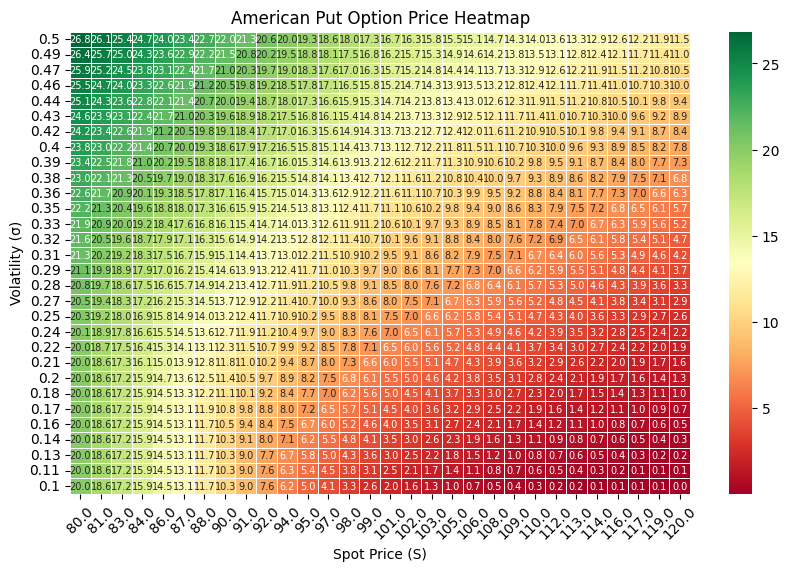

In [74]:
run_pricing_or_heatmap(
    mode='heatmap',
     K=100, T=1, r=0.055, N=10,
     option_type='put', style='american',
     spot_min=80, spot_max=120, spot_steps=30,
     vol_min=0.1, vol_max=0.5, vol_steps=30
 )


In [50]:
 run_pricing_or_heatmap(
     'pricing',
     S=100, K=100, T=1, r=0.05, sigma=0.2, N=5,
     option_type='call', style='american'
 )


Option Price: 10.805933920410096

Asset Price Tree: [[100.           0.           0.           0.           0.
    0.        ]
 [109.35646911  91.44406436   0.           0.           0.
    0.        ]
 [119.58837337 100.          83.62016907   0.           0.
    0.        ]
 [130.77762259 109.35646911  91.44406436  76.46568122   0.
    0.        ]
 [143.01379046 119.58837337 100.          83.62016907  69.92332675
    0.        ]
 [156.39483159 130.77762259 109.35646911  91.44406436  76.46568122
   63.94073192]]

Option Value Tree: [[10.80593392  0.          0.          0.          0.          0.        ]
 [16.12479602  4.94969818  0.          0.          0.          0.        ]
 [23.38533727  8.16032984  1.38078141  0.          0.          0.        ]
 [32.75775526 13.15964873  2.61288694  0.          0.          0.        ]
 [44.00880708 20.58339     4.9444308   0.          0.          0.        ]
 [56.39483159 30.77762259  9.35646911  0.          0.          0.        ]]



(np.float64(10.805933920410096),
 array([[100.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ],
        [109.35646911,  91.44406436,   0.        ,   0.        ,
           0.        ,   0.        ],
        [119.58837337, 100.        ,  83.62016907,   0.        ,
           0.        ,   0.        ],
        [130.77762259, 109.35646911,  91.44406436,  76.46568122,
           0.        ,   0.        ],
        [143.01379046, 119.58837337, 100.        ,  83.62016907,
          69.92332675,   0.        ],
        [156.39483159, 130.77762259, 109.35646911,  91.44406436,
          76.46568122,  63.94073192]]),
 array([[10.80593392,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ],
        [16.12479602,  4.94969818,  0.        ,  0.        ,  0.        ,
          0.        ],
        [23.38533727,  8.16032984,  1.38078141,  0.        ,  0.        ,
          0.        ],
        [32.75775526, 13.15964873,  2.61288694,  0.     

In [55]:
# code for app
st.set_page_config(layout="wide")
st.title("📈 Binomial Option Pricing & Heatmap Dashboard")

mode = st.sidebar.radio("Choose Mode:", ['Option Pricing', 'Heatmap'])

# Common inputs
option_type = st.sidebar.selectbox("Option Type", ['call', 'put'])
style = st.sidebar.selectbox("Option Style", ['european', 'american'])
K = st.sidebar.number_input("Strike Price (K)", value=100.0)
T = st.sidebar.number_input("Time to Maturity (T in years)", value=1.0, step=0.1)
r = st.sidebar.number_input("Risk-Free Rate (r)", value=0.05, step=0.005)
N = st.slider("Number of Steps", min_value=1, max_value=100, value=50, step=1)

if mode == 'Option Pricing':
    st.subheader("🔹 Binomial Option Pricing")

    S = st.number_input("Spot Price (S)", value=100.0)
    sigma = st.number_input("Volatility (σ)", value=0.2, step=0.01)

    if st.button("Calculate Option Price"):
        price, asset_tree, option_tree = binomial_option_pricing(S, K, T, r, sigma, N, option_type, style)
        st.success(f"Option Price: {price:.4f}")

        with st.expander("🔍 Asset Price Tree"):
            st.write(asset_tree)

        with st.expander("🔍 Option Value Tree"):
            st.write(option_tree)

elif mode == 'Heatmap':
    st.subheader("🔹 Option Price Heatmap")

    col1, col2 = st.columns(2)

    with col1:
        spot_min = st.number_input("Min Spot Price", value=80.0)
        spot_max = st.number_input("Max Spot Price", value=120.0)
        spot_steps = st.slider("Spot Steps", 5, 50, 20)

    with col2:
        vol_min = st.number_input("Min Volatility", value=0.1, step=0.01)
        vol_max = st.number_input("Max Volatility", value=0.5, step=0.01)
        vol_steps = st.slider("Volatility Steps", 5, 50, 20)

   # if st.button("Generate Heatmap"):
    option_price_heatmap(K, T, r, N, option_type, style,
                             spot_min, spot_max, spot_steps,
                             vol_min, vol_max, vol_steps)

2025-05-18 16:58:34.689 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-18 16:58:34.691 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-18 16:58:34.692 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-18 16:58:34.693 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-18 16:58:34.694 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-18 16:58:34.695 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-18 16:58:34.696 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-18 16:58:34.698 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar